# Data Loading & EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="muted")

In [ ]:
df = pd.read_csv('/content/cs-training.csv', index_col=0)

print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df['SeriousDlqin2yrs'].value_counts()}")
display(df.head())

Shape: (21128, 11)
Target distribution:
SeriousDlqin2yrs
0    19768
1     1360
Name: count, dtype: int64


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:

df.columns = [
    'target',                  # SeriousDlqin2yrs
    'util_rate',               # RevolvingUtilizationOfUnsecuredLines
    'age',                     # age
    'late_30_59',              # NumberOfTime30-59DaysPastDueNotWorse
    'debt_ratio',              # DebtRatio
    'monthly_income',          # MonthlyIncome
    'open_credits',            # NumberOfOpenCreditLinesAndLoans
    'late_90',                 # NumberOfTimes90DaysLate
    'real_estate_loans',       # NumberRealEstateLoansOrLines
    'late_60_89',              # NumberOfTime60-89DaysPastDueNotWorse
    'dependents'               # NumberOfDependents
]

print("Columns renamed ✓")
display(df.dtypes)

Columns renamed ✓


,0
target,int64
util_rate,float64
age,int64
late_30_59,int64
debt_ratio,float64
monthly_income,float64
open_credits,int64
late_90,int64
real_estate_loans,int64
late_60_89,int64


In [ ]:

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("=== Missing Values ===")
display(missing_df)


=== Missing Values ===


,Missing Count,Missing %
monthly_income,4246,20.10
dependents,581,2.75


In [ ]:

df['monthly_income'].fillna(df['monthly_income'].median(), inplace=True)
df['dependents'].fillna(df['dependents'].median(), inplace=True)

print(f"Missing after fix: {df.isnull().sum().sum()}")

Missing after fix: 0


/tmp/ipykernel_39450/2857453653.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['monthly_income'].fillna(df['monthly_income'].median(), inplace=True)
/tmp/ipykernel_39450/2857453653.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [ ]:

print("=== Age distribution ===")
print(df['age'].describe())
print(f"\nAge == 0: {(df['age'] == 0).sum()} rows ")
print(f"\nUtil rate > 1: {(df['util_rate'] > 1).sum()} rows")
print(f"Util rate > 10: {(df['util_rate'] > 10).sum()} rows ")

# Fix
df = df[df['age'] > 0]
df['util_rate'] = df['util_rate'].clip(upper=1.0)

print(f"\nShape after cleaning: {df.shape}")

=== Age distribution ===
count    21128.000000
mean        52.283415
std         14.779077
min         21.000000
25%         41.000000
50%         52.000000
75%         63.000000
max        103.000000
Name: age, dtype: float64

Age == 0: 0 rows 

Util rate > 1: 0 rows
Util rate > 10: 0 rows 

Shape after cleaning: (21128, 11)


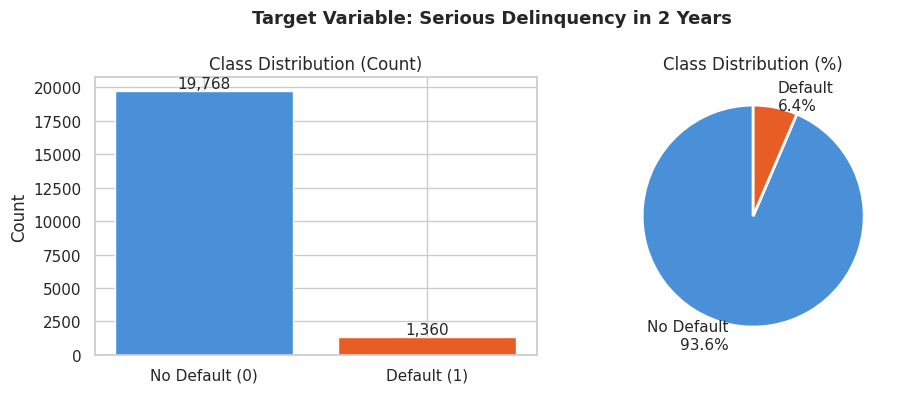


  Imbalance ratio: 93.6% vs 6.4%


In [ ]:

# Class imbalance
target_counts = df['target'].value_counts()
target_pct = df['target'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(['No Default (0)', 'Default (1)'],
            target_counts.values,
            color=['#4A90D9', '#E85D24'])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(target_pct.values,
            labels=[f'No Default\n{target_pct[0]:.1f}%',
                    f'Default\n{target_pct[1]:.1f}%'],
            colors=['#4A90D9', '#E85D24'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Target Variable: Serious Delinquency in 2 Years', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  Imbalance ratio: {target_pct[0]:.1f}% vs {target_pct[1]:.1f}%")

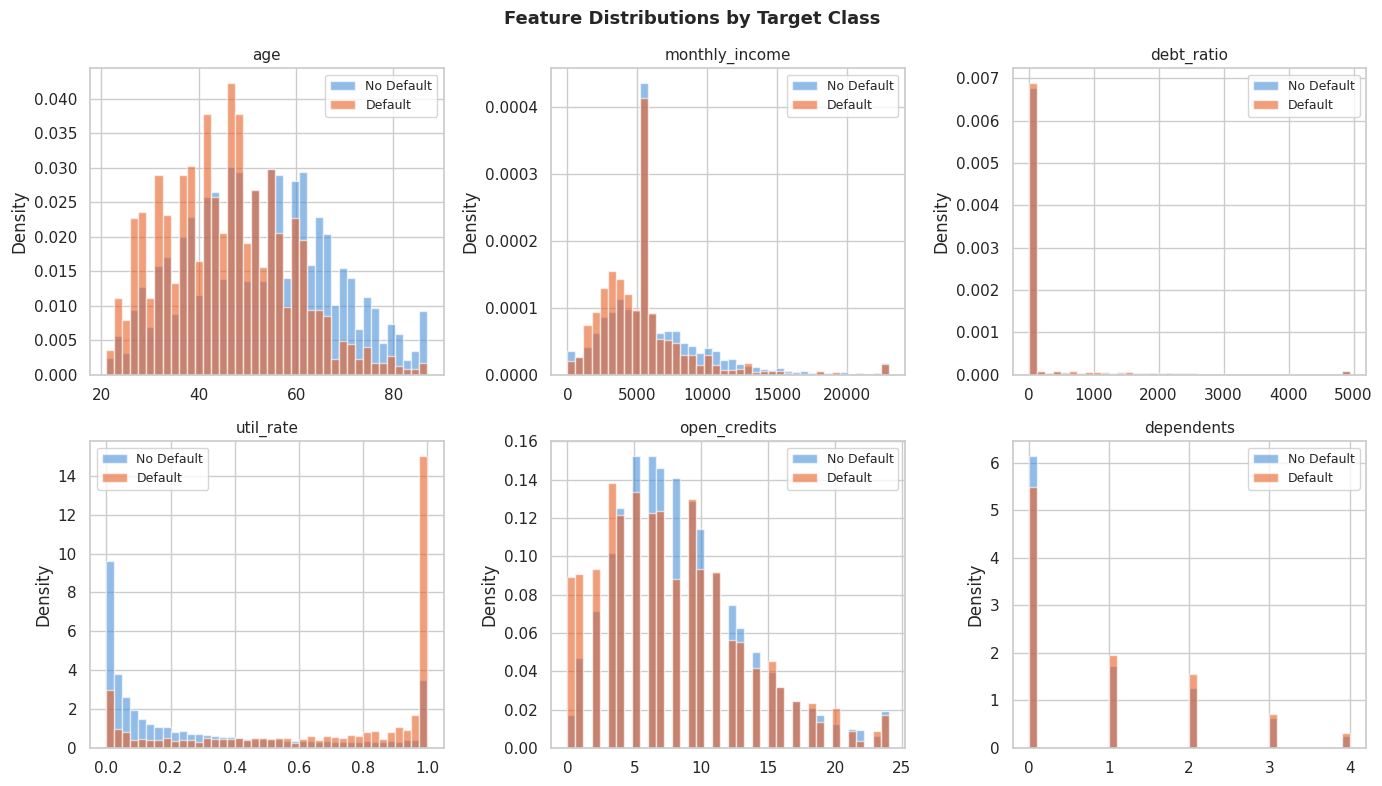

In [ ]:

#  Feature distributions

features = ['age', 'monthly_income', 'debt_ratio',
            'util_rate', 'open_credits', 'dependents']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    data_no  = df[df['target'] == 0][col]
    data_yes = df[df['target'] == 1][col]
    p99 = df[col].quantile(0.99)
    data_no  = data_no.clip(upper=p99)
    data_yes = data_yes.clip(upper=p99)

    axes[i].hist(data_no,  bins=40, alpha=0.6, label='No Default', color='#4A90D9', density=True)
    axes[i].hist(data_yes, bins=40, alpha=0.6, label='Default',    color='#E85D24', density=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions by Target Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../content/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

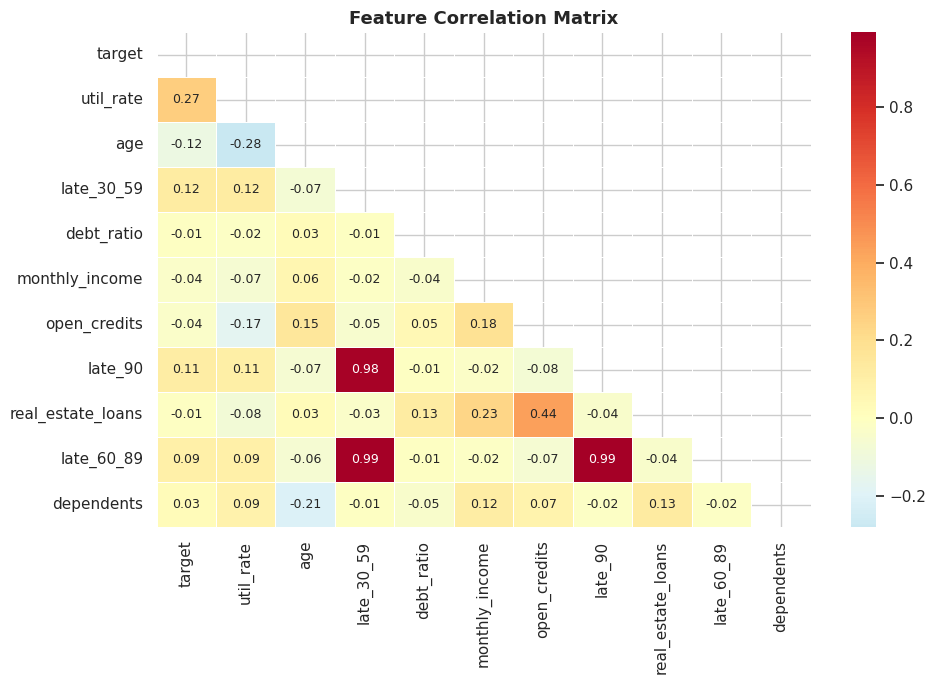

=== Key Correlations with Target ===


,target
util_rate,0.270710
late_30_59,0.117473
late_90,0.109501
late_60_89,0.094675
dependents,0.028972
real_estate_loans,-0.008968
debt_ratio,-0.010719
monthly_income,-0.035061
open_credits,-0.035406
age,-0.119244


In [ ]:

plt.figure(figsize=(10, 7))

corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 9}
)

plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../content/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# أهم observations
print("=== Key Correlations with Target ===")
target_corr = corr['target'].drop('target').sort_values(ascending=False)
display(target_corr)

In [ ]:

df.to_csv('../content/cs-training-clean.csv', index=False)
print(f" Saved cleaned data: {df.shape}")
print(f" Target rate: {df['target'].mean():.2%}")

 Saved cleaned data: (21128, 11)
 Target rate: 6.44%
